In [1]:
# Basic imports and setup
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 200

# Import the new data loader and plotting functions
from analyze_modules import ChelioRun, plot_all_iteration_profiles, plot_profile, plot_rcb_height

In [30]:
# Load a single simulation run
# All data loading, parsing, and iteration handling is done by ChelioRun.
output_folder = "../output/Atmodeller/"
run_name = "Earth_Tint=50_Tmelt=1000_Hocean=10.0_CtoH=0.1_NtoC=0.1_fO2=0"

# Load all iterations to see the evolution
run = ChelioRun(output_folder, run_name, load_mode='all')
run.read_data()

# Basic run info is now stored as attributes
print(f"Loaded {run.num_iterations_read} iterations for run: {run.run_name}")
print(f"Final convergence status: {run.final_convergence_status}")
print(f"Species found: {run.n_mol} molecules, {run.n_dust} condensates")

Loaded 12 iterations for run: Earth_Tint=50_Tmelt=1000_Hocean=10.0_CtoH=0.1_NtoC=0.1_fO2=0
Final convergence status: True
Species found: 52 molecules, 7 condensates


In [31]:
def set_white(ax):
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    ax.tick_params(axis='x', colors='white', which='both')  # Set color for both major and minor ticks
    ax.tick_params(axis='y', colors='white', which='both')  # Set color for both major and minor ticks

def increase_size(ax, linewidth=3, fontsize=14, legendcols=1, legendloc='best'):
    for l in ax.lines:
        l.set_linewidth(linewidth)
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(linewidth)
    ax.xaxis.set_tick_params(width=linewidth)
    ax.yaxis.set_tick_params(width=linewidth)
    ax.xaxis.label.set_size(fontsize)
    ax.yaxis.label.set_size(fontsize)
    ax.xaxis.set_tick_params(labelsize=fontsize)
    ax.yaxis.set_tick_params(labelsize=fontsize)
    ax.legend(fontsize=fontsize, ncols=legendcols, loc=legendloc)
    

(12, 93) (12, 93)
[55.2699 55.2699 55.2699 55.2699 55.2699 55.2699 55.2699 55.2699 55.2699
 55.2699 55.2699 55.2699]
[ 500.    1153.     301.611  222.1    204.207  203.975  203.857  203.796
  203.765  203.749  203.741  203.741]


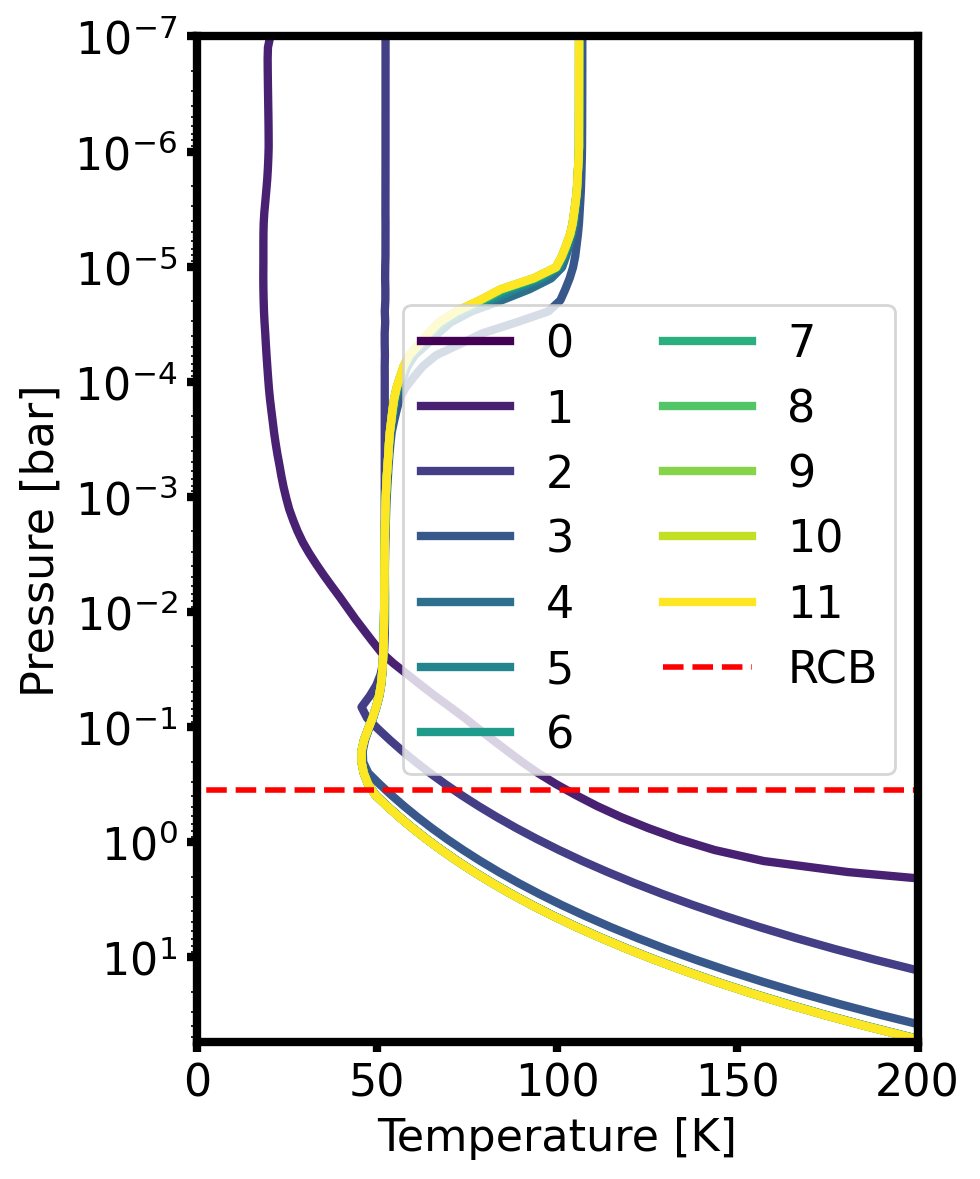

In [32]:
# Plot the T-P profile evolution across all iterations
fig, ax = plt.subplots(1, 1, figsize=(5, 6))

print(run.pressures_bar.shape, run.temperatures_K.shape)
print(run.pressures_bar[:,0])
print(run.temperatures_K[:,0])

# The new plotting utility handles the looping and coloring
plot_all_iteration_profiles(
    run, 
    'temperature', 
    y_axis='pressure', 
    ax=ax,
    cmap_name='viridis' #'Wistia'
)

# Add the RCB line using the dedicated function
plot_rcb_height(run, ax=ax, color='red', linestyle='--', linewidth=2, label='RCB')

ax.set_xlim(0, 200)
# set to max and min pressure
ax.set_ylim(run.pressures_bar.max(), run.pressures_bar.min())
ax.set_title(run.run_name.replace("_", ", "))

# turn on preferred options
#set_white(ax)
increase_size(ax, linewidth=3, fontsize=16, legendcols=2)
ax.set_title('')
plt.tight_layout()
#plt.savefig(f"images/JulyPoster/TPevolution_{run_name}.svg", format="svg", transparent=True)

plt.show()

log


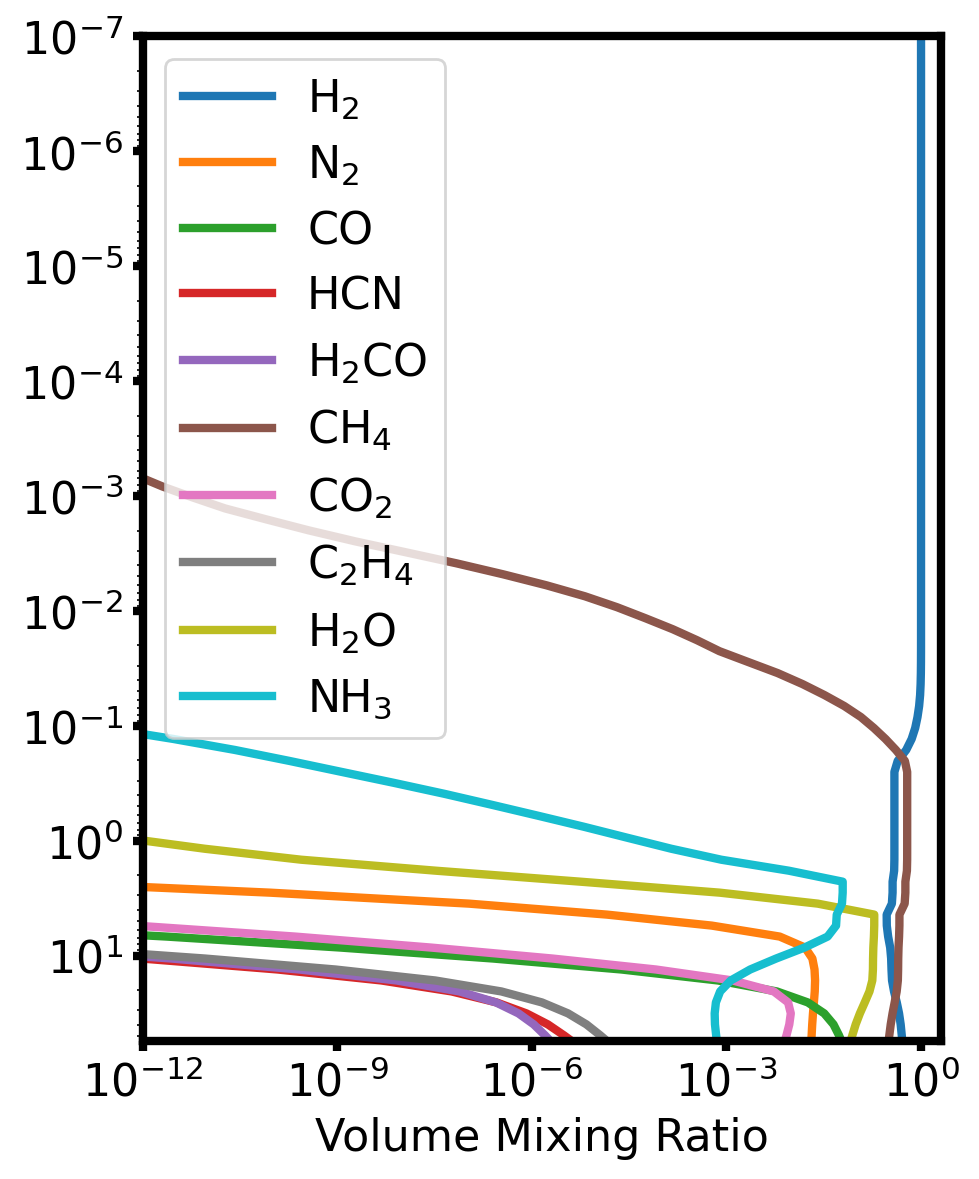

In [35]:
# Plot molecular mixing ratios for the final converged step
i = 1

# Find 
threshold = 1e-6

if threshold is not None:
    mask = run.mols_vmr[i] > threshold
    mask = np.any(mask, axis=0)
else:
    target_molecules = ['H2', 'H2O', 'CO2', 'CO', 'CH4', 'C2H2', 'C2H4']
    mask = np.isin(run.mol_names, target_molecules)

target_molecules = np.array(run.mol_names)[mask]

fig, ax = plt.subplots(1, 1, figsize=(5, 6))

# plot_profile can now take a list of molecules to plot
plot_profile(
    run, 
    param_key=target_molecules, 
    y_axis='pressure', 
    log_x=True, 
    ax=ax,
    iteration_index=i,
    mol_type='mol'
)

print(ax.get_xscale())

ax.set_xlim(1e-12, 2e0)
ax.set_ylim(run.pressures_bar.max(), run.pressures_bar.min())
ax.set_xlabel("Volume Mixing Ratio")
ax.set_title(run.run_name.replace("_", ", "))

# turn on preferred options
#set_white(ax)
increase_size(ax, linewidth=3, fontsize=16, legendcols=1)
ax.set_title('')
ax.set_ylabel('')
plt.tight_layout()
#plt.savefig(f"images/JulyPoster/FinalChem_{run_name}.svg", format="svg", transparent=True)

plt.show()

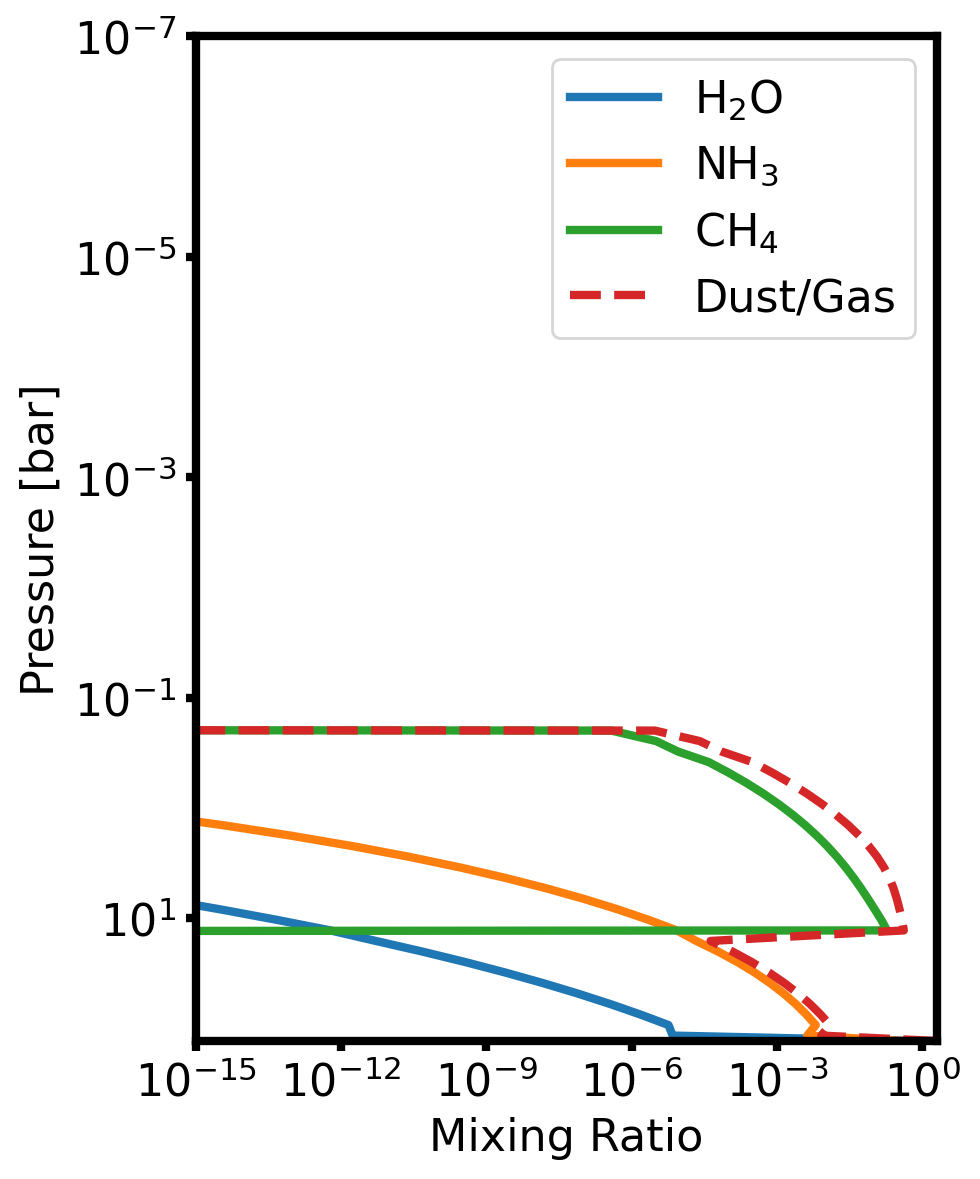

In [27]:
# plot the dust "mixing ratios"
i = -1

threshold = 1e-12

if threshold is not None:
    mask = run.dusts_vmr[i] > threshold
    mask = np.any(mask, axis=0)
else:
    target_molecules = run.dust_names #['H2', 'H2O', 'H2O[l]', 'CO2', 'CO', 'CH4', 'NH3']
    mask = np.isin(run.dust_names, target_molecules)
    #sort = np.argsort(mols[i][:,mask].max(axis=0))[::-1]

target_molecules = np.array(run.dust_names)[mask]

# Plot dust mixing ratios for the final converged step
fig, ax = plt.subplots(1, 1, figsize=(5, 6))

# We can directly use the list of dust names from the run object
plot_profile(
    run, 
    param_key=target_molecules,
    y_axis='pressure', 
    log_x=True, 
    ax=ax,
    iteration_index=i,
    mol_type='dust'
)

plot_profile(
    run, 
    param_key='dust_to_gas_mr',
    y_axis='pressure', 
    log_x=True, 
    ax=ax,
    iteration_index=i,
    label='Dust/Gas',
    linestyle='--'
)

ax.legend() # not called if plotting only one parameter

ax.set_xlim(1e-15, 2e0)
ax.set_ylim(run.pressures_bar.max(), run.pressures_bar.min())
ax.set_xlabel("Mixing Ratio")
ax.set_title(run.run_name.replace("_", ", "))

# turn on preferred options
#set_white(ax)
increase_size(ax, linewidth=3, fontsize=16, legendcols=1)
ax.set_title('')
plt.tight_layout()

plt.show()

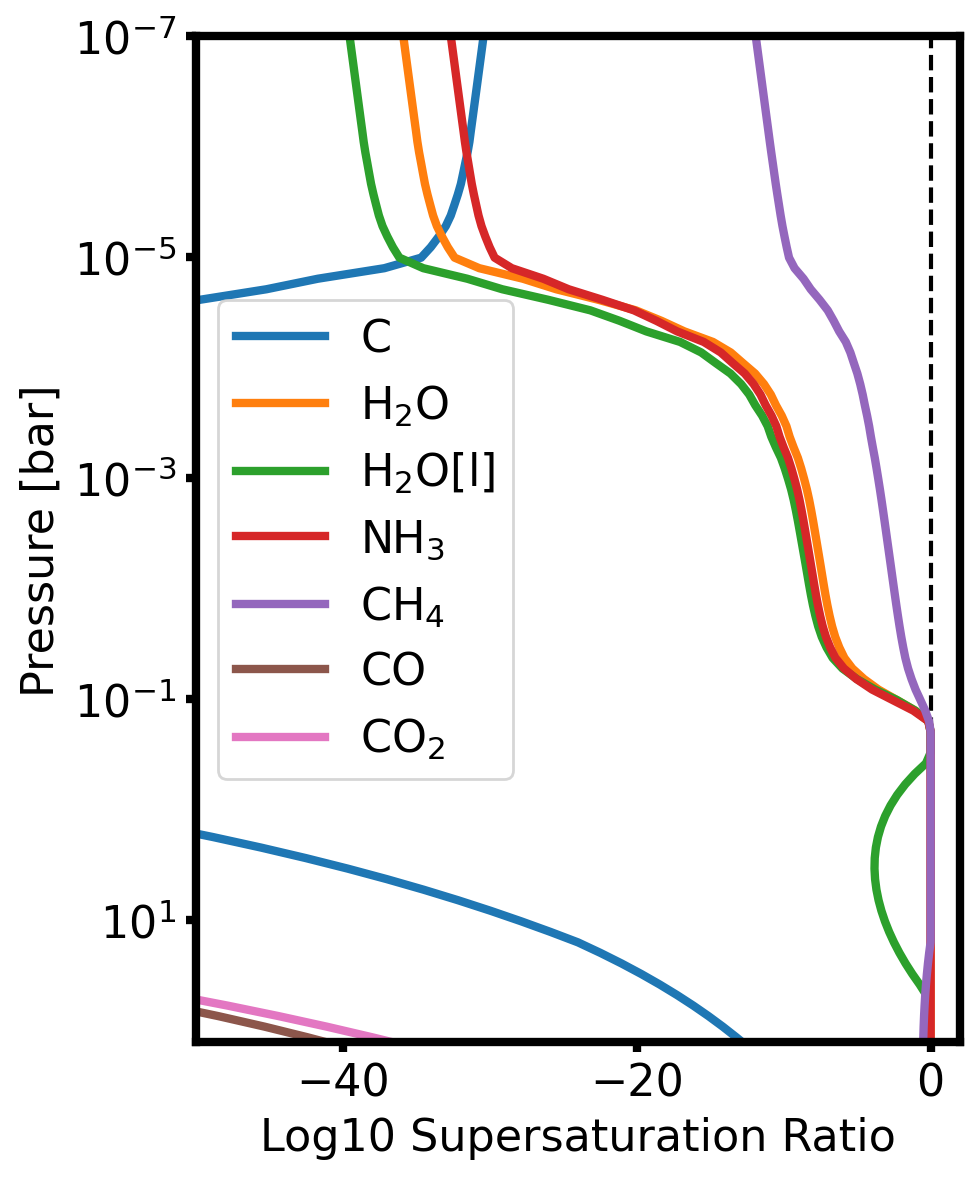

In [28]:
# plot supersaturation ratios of dust species
i = -1

threshold = None

if threshold is not None:
    mask = run.supersats[i] > threshold
    mask = np.any(mask, axis=0)
else:
    target_molecules = run.dust_names #['H2', 'H2O', 'H2O[l]', 'CO2', 'CO', 'CH4', 'NH3']
    mask = np.isin(run.dust_names, target_molecules)
    #sort = np.argsort(mols[i][:,mask].max(axis=0))[::-1]

target_molecules = np.array(run.dust_names)[mask]

# Plot supersaturation ratios for the final converged step
fig, ax = plt.subplots(1, 1, figsize=(5, 6))

# Plot reference line at 0 (1e0)
ax.vlines(0, run.pressures_bar.max(), run.pressures_bar.min(), linestyle='dashed', color='black')

# We can directly use the list of dust names from the run object
plot_profile(
    run, 
    param_key=target_molecules,
    y_axis='pressure', 
    log_x=False, 
    ax=ax,
    iteration_index=i,
    mol_type='supersat'
)

ax.set_xlim(-50, 2)
ax.set_ylim(run.pressures_bar.max(), run.pressures_bar.min())
ax.set_xlabel("Log10 Supersaturation Ratio")
ax.set_title(run.run_name.replace("_", ", "))

# turn on preferred options
#set_white(ax)
increase_size(ax, linewidth=3, fontsize=16, legendcols=1)
ax.set_title('')
plt.tight_layout()

plt.show()

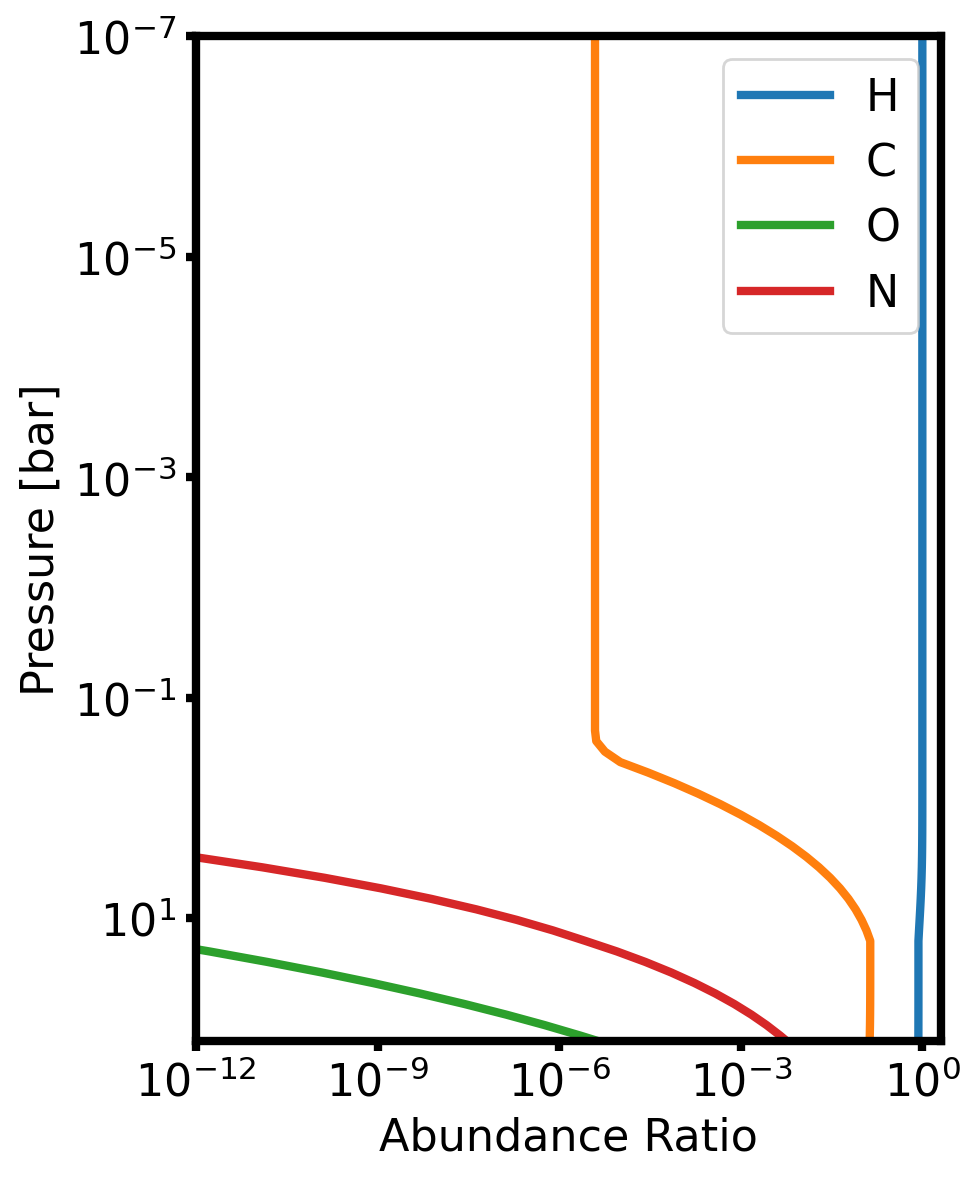

In [29]:
# plot abundance ratios of atoms and dust/gas ratio
i = -1

fig, ax = plt.subplots(1, 1, figsize=(5, 6))

# We can directly use the list of dust names from the run object
plot_profile(
    run, 
    param_key=run.atom_names[1:],
    y_axis='pressure', 
    log_x=True, 
    ax=ax,
    iteration_index=i,
    mol_type='eps'
)

ax.set_xlim(1e-12, 2e0)
ax.set_ylim(run.pressures_bar.max(), run.pressures_bar.min())
ax.set_xlabel("Abundance Ratio")
ax.set_title(run.run_name.replace("_", ", "))

# turn on preferred options
#set_white(ax)
increase_size(ax, linewidth=3, fontsize=16, legendcols=1)
ax.set_title('')
plt.tight_layout()

plt.show()